# 탐색적 데이터 분석 (EDA)

화장품 섹터 실적 발표와 주가 반응 분석 — 데이터를 실제로 들여다본 기록.

**이 노트북의 위치**
- 분석 파이프라인은 `src/01~14` 스크립트가 담당한다. 여기서는 데이터를 **다시 만들지 않는다.**
- 이미 저장된 `data/*.csv` 만 읽어서, 분석 과정에서 무엇을 보고 무엇을 판단했는지 남긴다.
- 결론과 방법론은 [`README.md`](../README.md), 의사결정 전체 기록은 [`docs/design-log.md`](../docs/design-log.md) 참조.

**여기서 답하려는 질문**

1. 종속변수(CAR)는 어떻게 생겼나
2. 극단값이 실제 거래인가, 계산 오류인가
3. 특정 종목이 결과를 끌고 가지는 않나
4. 특성들은 어떤 분포이고 서로 어떤 관계인가

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 노트북을 어디서 열든 저장소 루트를 찾는다
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA = ROOT / "data"

# 그림 스타일 (src/12_visualize.py 와 동일한 팔레트)
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"

mpl.rcParams.update({
    "font.family": "Malgun Gothic", "axes.unicode_minus": False,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": BASELINE, "font.size": 10,
    "figure.dpi": 110,
})

def style(ax, axis="y"):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.grid(axis=axis, color=GRID, linewidth=1)
    ax.set_axisbelow(True)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

df = pd.read_csv(DATA / "dataset.csv", dtype={"종목코드": str}, parse_dates=["발표일", "거래일t0"])
prices = pd.read_csv(DATA / "prices.csv", dtype={"종목코드": str}, parse_dates=["일자"])

print(f"전체 이벤트 {len(df)}건 / 주가 {len(prices):,}행")

전체 이벤트 176건 / 주가 13,527행


---
## 1. 데이터 개요

전체 이벤트에서 분석 표본이 어떻게 걸러졌는지부터 확인한다.

In [2]:
smp = df[df["분석표본"]].reset_index(drop=True)

단계 = pd.DataFrame([
    ("전체 이벤트",            len(df)),
    ("v1 종목만",             (df["포함버전"] == "v1").sum()),
    ("+ CAR 산출됨",          ((df["포함버전"] == "v1") & df["CAR_0_1"].notna()).sum()),
    ("+ 상장 직후 제외",       ((df["포함버전"] == "v1") & df["CAR_0_1"].notna() & ~df["상장직후"]).sum()),
    ("+ 특성 결측 없음 (최종)", df["분석표본"].sum()),
], columns=["단계", "건수"])
단계

,단계,건수
0,전체 이벤트,176
1,v1 종목만,160
2,+ CAR 산출됨,160
3,+ 상장 직후 제외,155
4,+ 특성 결측 없음 (최종),155


In [3]:
smp.groupby(["유형", "종목명"]).size().rename("이벤트").reset_index()

,유형,종목명,이벤트
0,ODM,코스맥스,16
1,ODM,코스메카코리아,16
2,ODM,한국콜마,16
3,브랜드,네오팜,16
4,브랜드,달바글로벌,3
5,브랜드,브이티,16
6,브랜드,아모레퍼시픽,16
7,브랜드,에이피알,8
8,브랜드,클리오,16
9,유통,실리콘투,16


11종목 중 9종목이 16분기를 모두 채웠다.
에이피알(8건)과 달바글로벌(3건)은 상장이 늦어 관측이 적다.
표본 수가 종목마다 다른 **불균형 패널**이지만, 각 이벤트가 독립 관측치이므로 분석에는 지장이 없다.

---
## 2. 종속변수 CAR 은 어떻게 생겼나

가장 먼저 볼 것은 설명하려는 대상 자체의 모양이다.

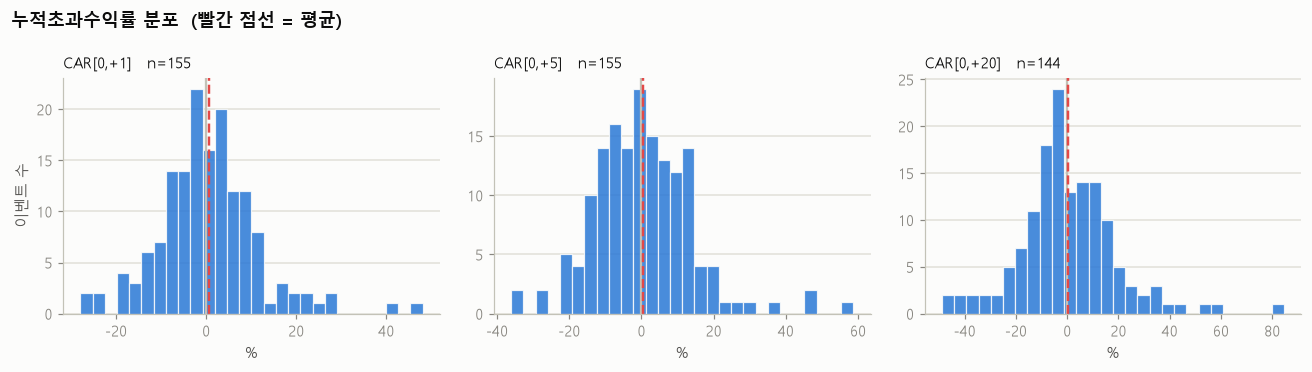

,count,mean,std,min,25%,50%,75%,max
CAR_0_1,155.0,0.005557,0.111483,-0.279422,-0.056274,-0.002672,0.055863,0.480623
CAR_0_5,155.0,0.005548,0.139820,-0.361256,-0.083038,0.001728,0.085035,0.587064
CAR_0_20,144.0,0.001576,0.191988,-0.489224,-0.099289,-0.016864,0.097546,0.846581


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, col, label in zip(axes, ["CAR_0_1", "CAR_0_5", "CAR_0_20"],
                          ["CAR[0,+1]", "CAR[0,+5]", "CAR[0,+20]"]):
    s = smp[col].dropna() * 100
    ax.hist(s, bins=28, color=BLUE, alpha=0.85, edgecolor=SURFACE, linewidth=0.8)
    ax.axvline(0, color=BASELINE, linewidth=1.5)
    ax.axvline(s.mean(), color=RED, linewidth=1.6, linestyle="--")
    ax.set_title(f"{label}   n={len(s)}", fontsize=10, color=INK, loc="left")
    ax.set_xlabel("%")
    style(ax)
axes[0].set_ylabel("이벤트 수")
fig.suptitle("누적초과수익률 분포  (빨간 점선 = 평균)", x=0.01, ha="left",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

smp[["CAR_0_1", "CAR_0_5", "CAR_0_20"]].describe().T

**관찰**

- 평균은 0 근처다. 이벤트 스터디에서 정상적인 결과다. 시장이 효율적이라면 발표 자체로 평균적인 초과수익이 생기지는 않는다. 우리가 볼 것은 평균이 아니라 **항목별 횡단면 차이**다.
- **꼬리가 두껍다.** CAR[0,+1] 표준편차가 11.1%인데, 2거래일 구간치고 상당히 크다.

일간 수익률 표준편차가 3.5% 정도이니 단순 계산으로는 `√2 × 3.5% ≈ 5%`가 나와야 한다.
실측이 그 두 배다. 계산이 틀렸을 가능성을 먼저 의심해야 한다.

In [5]:
# 발표일 당일 수익률만 뽑아 평상시와 비교한다
t0 = smp[["종목코드", "거래일t0"]].dropna()
발표일수익률 = prices.merge(
    t0, left_on=["종목코드", "일자"], right_on=["종목코드", "거래일t0"], how="inner"
)["수익률"].dropna()
전체수익률 = prices["수익률"].dropna()

print(f"평상시 일간 수익률 표준편차 : {전체수익률.std():.2%}")
print(f"발표일 당일 표준편차        : {발표일수익률.std():.2%}   (n={len(발표일수익률)})")
print(f"배수                        : {발표일수익률.std() / 전체수익률.std():.2f}배")
print()
print(f"√2 × 발표일 표준편차        : {2**0.5 * 발표일수익률.std():.2%}")
print(f"실측 CAR[0,+1] 표준편차     : {smp['CAR_0_1'].std():.2%}")

평상시 일간 수익률 표준편차 : 3.46%
발표일 당일 표준편차        : 7.16%   (n=155)
배수                        : 2.07배

√2 × 발표일 표준편차        : 10.12%
실측 CAR[0,+1] 표준편차     : 11.15%


**발견 — 계산 오류가 아니었다.**

발표일 당일 변동성이 평상시의 **2배**다. 그 값으로 다시 계산하면 실측 CAR 표준편차와 맞아떨어진다.

> 배수는 표본을 어디까지 잡느냐에 따라 2.03~2.07 사이에서 조금씩 달라진다.
> 여기서는 분석표본 155건 기준이고, README·보고서의 2.03배는 CAR 이 산출된 전체 176건 기준이다.
> 어느 쪽이든 결론은 같다.

그리고 이것 자체가 결과다. 어떤 항목이 중요한지는 아직 몰라도,
**"실적 발표가 주가를 움직인다"는 전제는 데이터로 확인됐다.**

---
## 3. 극단값이 진짜인가

CAR 이 +48% 인 이벤트가 있다. 2거래일 만에 48%는 의심스럽다.
계산 결과를 믿기 전에 **원본 종가로 되짚어 확인한다.**

In [6]:
def 발표전후(row, before=2, after=3):
    px = prices[prices["종목코드"] == row["종목코드"]].sort_values("일자").reset_index(drop=True)
    i = px.index[px["일자"] == row["거래일t0"]]
    if len(i) == 0:
        return None
    i = int(i[0])
    w = px.iloc[max(0, i - before): i + after + 1].copy()
    w["시점"] = [f"t{j - i:+d}" if j != i else "t0" for j in w.index]
    w["종목"] = row["종목명"]
    w["분기"] = row["분기"]
    return w[["종목", "분기", "시점", "일자", "종가", "수익률"]]

극단 = smp.nlargest(3, "CAR_0_1")
for _, r in 극단.iterrows():
    print(f"\n{r['종목명']} {r['분기']}   CAR[0,+1] = {r['CAR_0_1']:+.2%}")
    print(발표전후(r).to_string(index=False, formatters={"수익률": "{:+.2%}".format}))


실리콘투 2024Q1   CAR[0,+1] = +48.06%
  종목     분기  시점         일자    종가     수익률
실리콘투 2024Q1 t-2 2024-05-07 15960  +5.70%
실리콘투 2024Q1 t-1 2024-05-08 15560  -2.51%
실리콘투 2024Q1  t0 2024-05-09 20200 +29.82%
실리콘투 2024Q1 t+1 2024-05-10 26250 +29.95%
실리콘투 2024Q1 t+2 2024-05-13 26650  +1.52%
실리콘투 2024Q1 t+3 2024-05-14 27000  +1.31%

실리콘투 2023Q1   CAR[0,+1] = +41.50%
  종목     분기  시점         일자   종가     수익률
실리콘투 2023Q1 t-2 2023-05-04 3075  -2.07%
실리콘투 2023Q1 t-1 2023-05-08 3075  +0.00%
실리콘투 2023Q1  t0 2023-05-09 3855 +25.37%
실리콘투 2023Q1 t+1 2023-05-10 4545 +17.90%
실리콘투 2023Q1 t+2 2023-05-11 4470  -1.65%
실리콘투 2023Q1 t+3 2023-05-12 4595  +2.80%

에이피알 2025Q1   CAR[0,+1] = +28.47%
  종목     분기  시점         일자     종가     수익률
에이피알 2025Q1 t-2 2025-05-02  76200  +1.20%
에이피알 2025Q1 t-1 2025-05-07  76400  +0.26%
에이피알 2025Q1  t0 2025-05-08  98400 +28.80%
에이피알 2025Q1 t+1 2025-05-09 102700  +4.37%
에이피알 2025Q1 t+2 2025-05-12 102500  -0.19%
에이피알 2025Q1 t+3 2025-05-13 109100  +6.44%


**결론 — 실제 거래였다.**

실리콘투는 발표 당일과 다음 날 **연속 상한가**(+29.8%, +30.0%)를 기록했다.
국내 증시 일일 상하한가가 ±30%이므로 이보다 큰 값은 나올 수 없고, 실제로 그 상한에 붙어 있다.

버그가 아니라 화장품 중소형주가 실적에 격렬하게 반응한 사례다. 표본에서 제거할 이유가 없다.

In [7]:
# 수정주가가 제대로 반영됐다면 ±30% 를 넘는 일간 수익률은 없어야 한다
초과 = prices[prices["수익률"].abs() > 0.31]
print(f"±30% 초과 일간 수익률: {len(초과)}건")
print("→ 0건이면 액면분할·병합이 수정주가에 반영됐다는 뜻")

±30% 초과 일간 수익률: 0건
→ 0건이면 액면분할·병합이 수정주가에 반영됐다는 뜻


---
## 4. 특정 종목이 결과를 끌고 가지는 않나

표본이 155건인데 한 종목이 극단값을 독차지하면, 그 종목 몇 건이 회귀 결과를 좌우할 수 있다.
종목별 변동성을 확인한다.

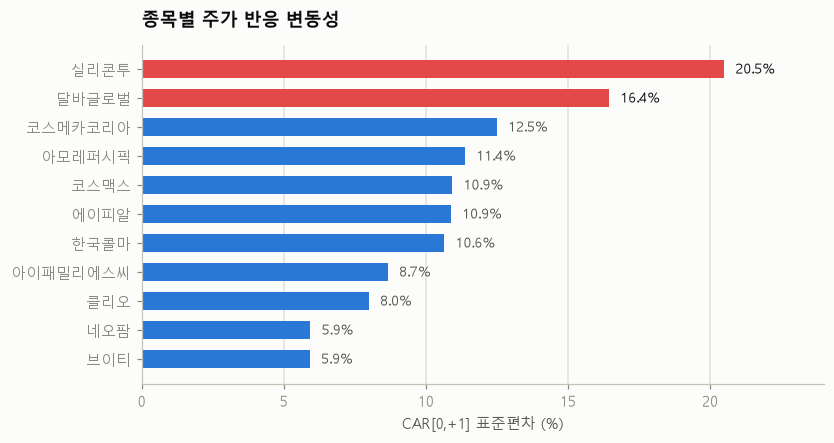

,건수,평균,표준편차
종목명,,,
실리콘투,16,+0.025,0.205
달바글로벌,3,+0.031,0.164
코스메카코리아,16,+0.002,0.125
아모레퍼시픽,16,+0.015,0.114
코스맥스,16,-0.001,0.109
에이피알,8,+0.057,0.109
한국콜마,16,+0.002,0.106
아이패밀리에스씨,16,-0.023,0.087
클리오,16,-0.010,0.080


In [8]:
by_stock = (smp.groupby("종목명")["CAR_0_1"]
              .agg(건수="count", 평균="mean", 표준편차="std")
              .sort_values("표준편차", ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(by_stock))
색 = [RED if v > 0.15 else BLUE for v in by_stock["표준편차"]]
ax.barh(y, by_stock["표준편차"] * 100, color=색, height=0.62)
ax.set_yticks(y)
ax.set_yticklabels(by_stock.index)
ax.invert_yaxis()
ax.set_xlabel("CAR[0,+1] 표준편차 (%)")
ax.set_title("종목별 주가 반응 변동성", fontsize=12, fontweight="bold", loc="left", pad=12)
for i, v in enumerate(by_stock["표준편차"] * 100):
    ax.text(v + 0.4, i, f"{v:.1f}%", va="center", fontsize=9,
            color=INK if v > 15 else INK2)
ax.set_xlim(0, 24)
style(ax, axis="x")
plt.show()

by_stock.style.format({"평균": "{:+.3f}", "표준편차": "{:.3f}"})

**실리콘투가 눈에 띈다.** 표준편차 20.5%로 2위(달바글로벌 16.1%)와도 격차가 크고,
CAR 상하위 5건 중 4건이 이 종목이다.

제거할 근거는 없다. 데이터 오류가 아니라 실제로 변동성이 큰 종목이기 때문이다.
대신 **이 종목을 뺀 회귀를 강건성 검증에 포함**해서, 결론이 이 종목에 의존하지 않는지 확인하기로 했다.
(결과: 추세이탈도 계수가 +0.576 → +0.493 으로 줄지만 유의성은 유지된다.)

---
## 5. 특성들의 분포

독립변수 6개가 각각 어떻게 생겼는지 본다.

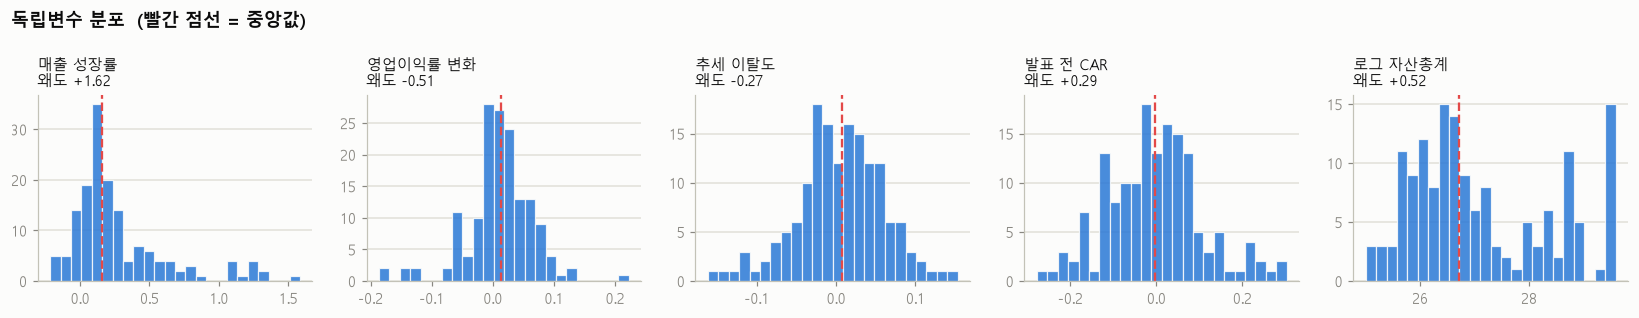

,count,mean,std,min,25%,50%,75%,max
매출YoY,155.0,0.277247,0.352112,-0.215731,0.068380,0.158772,0.384144,1.584417
OPM변화,155.0,0.010781,0.055135,-0.186078,-0.009603,0.013032,0.044720,0.222512
추세이탈도,155.0,0.004885,0.054466,-0.161542,-0.027325,0.007618,0.041047,0.153316
CAR_PRE,155.0,-0.004622,0.110024,-0.277867,-0.081570,-0.003710,0.057631,0.303007
로그자산,155.0,27.131119,1.288042,25.004555,26.139283,26.717751,28.277206,29.589338


In [9]:
특성 = ["매출YoY", "OPM변화", "추세이탈도", "CAR_PRE", "로그자산"]
라벨 = ["매출 성장률", "영업이익률 변화", "추세 이탈도", "발표 전 CAR", "로그 자산총계"]

fig, axes = plt.subplots(1, 5, figsize=(15, 2.9))
for ax, c, l in zip(axes, 특성, 라벨):
    s = smp[c].dropna()
    ax.hist(s, bins=24, color=BLUE, alpha=0.85, edgecolor=SURFACE, linewidth=0.8)
    ax.axvline(s.median(), color=RED, linewidth=1.5, linestyle="--")
    ax.set_title(f"{l}\n왜도 {s.skew():+.2f}", fontsize=9.5, color=INK, loc="left")
    style(ax)
fig.suptitle("독립변수 분포  (빨간 점선 = 중앙값)", x=0.01, ha="left",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

smp[특성].describe().T

**관찰**

- **매출 성장률의 오른쪽 꼬리가 길다** (왜도 +1.6). 에이피알·실리콘투·브이티의 급성장 구간 때문이다. 최댓값이 +158%다. 윈저라이징 강건성 검증이 필요한 이유다.
- **추세 이탈도와 발표 전 CAR 은 0 중심으로 대칭**이다. 설계 의도대로다. 추세 대비 편차이므로 평균이 0 근처여야 정상이다.
- **로그 자산총계는 이봉(二峰) 형태**에 가깝다. 대형주(아모레퍼시픽·에이피알)와 중소형주 사이에 규모 격차가 크기 때문이다.

In [10]:
# 전환 더미는 실제로 몇 건이나 발생했나
더미 = pd.DataFrame({
    "건수": [int(smp[c].sum()) for c in ["흑자전환", "적자전환", "적자지속", "잠정실적더미"]],
    "비율": [f"{smp[c].mean():.1%}" for c in ["흑자전환", "적자전환", "적자지속", "잠정실적더미"]],
}, index=["흑자전환", "적자전환", "적자지속", "잠정실적더미"])
더미

,건수,비율
흑자전환,1,0.6%
적자전환,0,0.0%
적자지속,0,0.0%
잠정실적더미,116,74.8%


**전환 더미를 특성에서 뺀 이유가 여기 있다.**

적자 기저 문제에 대비해 설계했지만, 실제 표본에는 흑자전환 1건뿐이고 적자전환·적자지속은 0건이다.
분석 대상 11종목이 4년 내내 흑자 기조였다.

**1건짜리 더미는 해롭다.** 회귀에서 그 관측치 하나를 완벽하게 설명해버리기 때문이다.

---
## 6. 변수 간 관계

회귀를 돌리기 전에 상관 구조를 먼저 본다. 다중공선성 여부와 예상 방향을 가늠하기 위해서다.

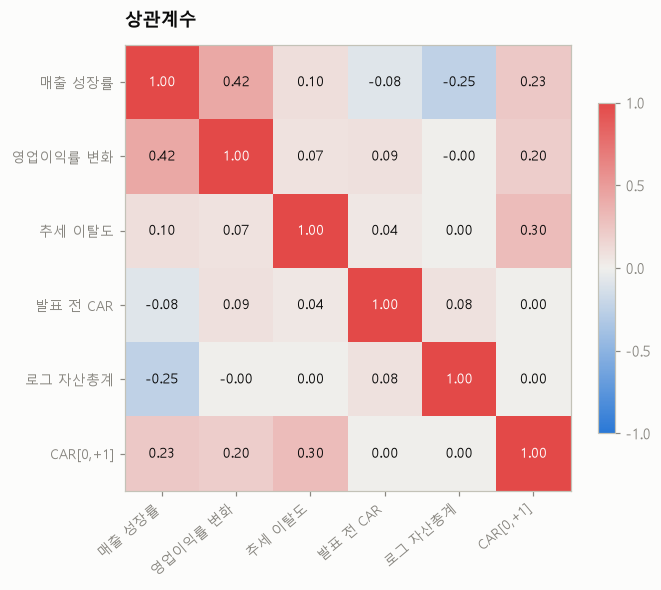

In [11]:
cols = 특성 + ["CAR_0_1"]
corr = smp[cols].corr()

# 상관계수는 음/양 양극이 있으므로 발산형 색을 쓴다 (파랑 ↔ 회색 ↔ 빨강)
cmap = mpl.colors.LinearSegmentedColormap.from_list("div", [BLUE, "#f0efec", RED])

fig, ax = plt.subplots(figsize=(6.4, 5.4))
im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)
이름 = 라벨 + ["CAR[0,+1]"]
ax.set_xticks(range(len(cols)), 이름, rotation=40, ha="right", fontsize=9)
ax.set_yticks(range(len(cols)), 이름, fontsize=9)
for i in range(len(cols)):
    for j in range(len(cols)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(v) > 0.55 else INK)
ax.set_title("상관계수", fontsize=12, fontweight="bold", loc="left", pad=12)
fig.colorbar(im, ax=ax, shrink=0.72, ticks=[-1, -0.5, 0, 0.5, 1])
fig.tight_layout()
plt.show()

**관찰**

- **추세 이탈도가 CAR 과 가장 높은 상관(0.30)**을 보인다. 회귀 결과와 일치하는 방향이다.
- 매출 성장률과 영업이익률 변화가 0.42로 서로 상관이 있다. 둘 다 실적 개선을 반영하니 당연하다. 다만 다중공선성을 걱정할 수준은 아니다 (VIF 전부 1.4 미만).
- **발표 전 CAR 은 CAR[0,+1]과 상관이 0.00**이다. 선반영이 있다면 음의 상관이 나와야 하는데 없다. 예상이 빗나간 지점이다.

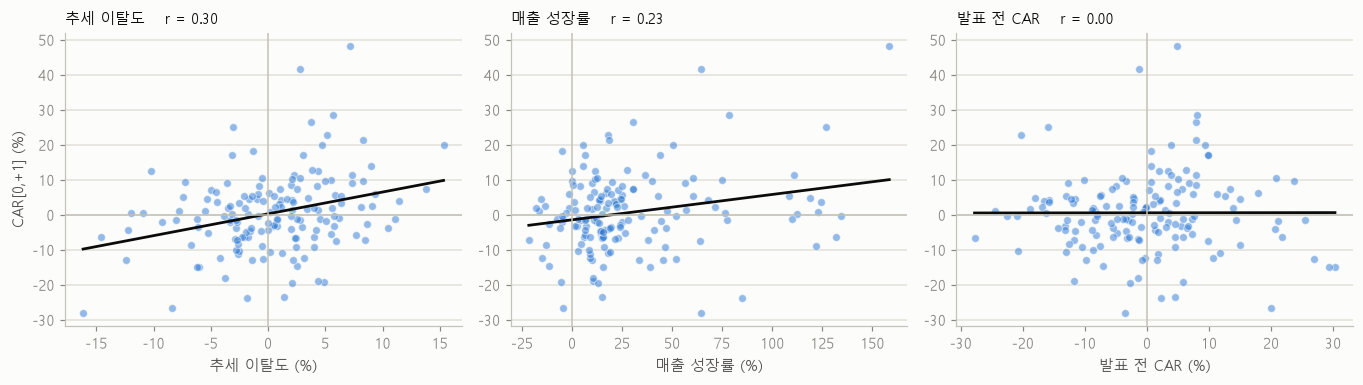

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
for ax, c, l in zip(axes, ["추세이탈도", "매출YoY", "CAR_PRE"],
                    ["추세 이탈도", "매출 성장률", "발표 전 CAR"]):
    x, y = smp[c] * 100, smp["CAR_0_1"] * 100
    ax.scatter(x, y, s=26, color=BLUE, alpha=0.5, edgecolor=SURFACE, linewidth=0.7)
    b, a = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, a + b * xs, color=INK, linewidth=1.8)
    ax.axhline(0, color=BASELINE, linewidth=1)
    ax.axvline(0, color=BASELINE, linewidth=1)
    ax.set_title(f"{l}    r = {np.corrcoef(x, y)[0,1]:.2f}", fontsize=10,
                 color=INK, loc="left")
    ax.set_xlabel(f"{l} (%)")
    style(ax)
axes[0].set_ylabel("CAR[0,+1] (%)")
fig.tight_layout()
plt.show()

왼쪽 둘은 우상향이 보인다. 오른쪽(발표 전 CAR)은 기울기가 거의 없다.

동시에 **세 그림 모두 흩어짐이 크다**. 관계가 있어도 개별 예측력은 제한적이라는 뜻이고,
최종 모형의 R² 0.146 과 일관된다.

---
## 7. 시기에 따른 변화

4년은 짧지 않다. 시기별로 패턴이 달라지면 고정효과나 레짐 통제를 고려해야 한다.

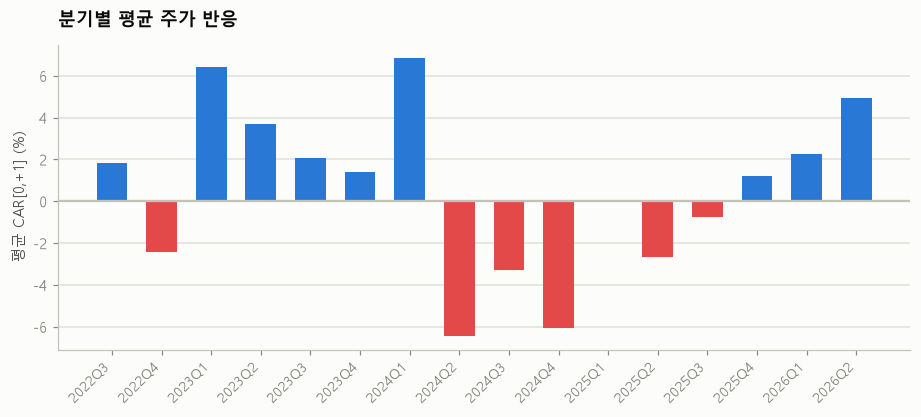

,분기,건수,평균CAR,평균성장
0,2022Q3,9,+1.85%,+14.8%
1,2022Q4,9,-2.42%,+6.5%
2,2023Q1,9,+6.43%,+15.9%
3,2023Q2,9,+3.68%,+33.1%
4,2023Q3,9,+2.06%,+36.2%
5,2023Q4,9,+1.38%,+36.5%
6,2024Q1,9,+6.83%,+49.5%
7,2024Q2,9,-6.43%,+33.5%
8,2024Q3,10,-3.27%,+26.5%
9,2024Q4,10,-6.06%,+23.6%


In [13]:
분기별 = (smp.groupby("분기")
            .agg(건수=("CAR_0_1", "count"),
                 평균CAR=("CAR_0_1", "mean"),
                 평균성장=("매출YoY", "mean"))
            .reset_index())

fig, ax = plt.subplots(figsize=(10, 3.6))
x = np.arange(len(분기별))
색 = [BLUE if v >= 0 else RED for v in 분기별["평균CAR"]]
ax.bar(x, 분기별["평균CAR"] * 100, color=색, width=0.62)
ax.axhline(0, color=BASELINE, linewidth=1.5)
ax.set_xticks(x, 분기별["분기"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("평균 CAR[0,+1] (%)")
ax.set_title("분기별 평균 주가 반응", fontsize=12, fontweight="bold", loc="left", pad=12)
style(ax)
plt.show()

분기별.style.format({"평균CAR": "{:+.2%}", "평균성장": "{:+.1%}"})

분기마다 평균 CAR 이 오르내리지만 **뚜렷한 추세나 구조적 단절은 보이지 않는다.**
2024년 중반에 음수가 몇 분기 이어지는데, 이 시기 화장품 섹터 전반이 조정을 받은 구간과 겹친다.

각 분기 표본이 9~11건으로 작아 분기 고정효과를 넣으면 자유도 손실이 크다.
대신 **섹터 지수를 벤치마크에 포함**해 시기 공통 요인을 제거하는 방식을 택했다.

---
## 8. 탐색에서 얻은 것

| 확인한 것 | 결과 | 분석 설계에 반영된 방식 |
|---|---|---|
| CAR 표준편차가 비정상적으로 큰가 | 아니다. 발표일 변동성이 평상시의 2배 | 그대로 사용 |
| 극단값(+48%)이 오류인가 | 아니다. 상한가 2연속, 실제 거래 | 제거하지 않음 |
| 수정주가가 반영됐는가 | ±30% 초과 0건, 정상 | — |
| 한 종목이 결과를 끌고 가는가 | 실리콘투 변동성이 압도적 | 해당 종목 제외 모형을 강건성 검증에 포함 |
| 매출 성장률 분포 | 오른쪽 꼬리가 김 (최대 +158%) | 윈저라이징 강건성 검증 추가 |
| 전환 더미가 쓸모 있는가 | 흑자전환 1건, 나머지 0건 | 특성에서 제외 |
| 다중공선성 | 최대 상관 0.42, VIF 1.4 미만 | 문제 없음, 전 변수 유지 |
| 선반영이 관찰되는가 | 상관 0.00 | 예상 빗나감. 한계로 기재 |
| 시기별 구조 변화 | 뚜렷하지 않음 | 분기 고정효과 대신 섹터 벤치마크 사용 |

**탐색이 분석 설계를 바꾼 지점이 세 개**다. 전환 더미 제외, 윈저라이징 추가, 실리콘투 제외 모형 추가.
데이터를 보지 않고 계획대로만 돌렸다면 셋 다 놓쳤을 것이다.

---

이어지는 내용: [`README.md`](../README.md) · [`docs/design-log.md`](../docs/design-log.md) · [`report.html`](../report.html)